# Case Study Assignment 1 — Superconductor Critical Temperature Prediction
**Name:** Chloe Barker  
**Course:** DS-7333: Quantifying The World

## Problem Statement
Build regularized linear regression models (L1 / Lasso and L2 / Ridge) to predict the **critical temperature** at which a superconductor loses electrical resistance. Identify the top 10 most important variables for each model.

## Dataset Overview
| File | Rows | Columns | Description |
|---|---|---|---|
| `train.csv` | 21,263 | 82 | 81 numeric features per superconductor + `critical_temp` |
| `unique_m.csv` | 21,263 | 88 | One-hot encoded element presence + `critical_temp` + `material` formula |

The two files share the same row order and are linked by `critical_temp`. We merge them to enrich the feature set with elemental composition.

## Step 1: Import Libraries

We load the standard scientific Python stack:
- **pandas / numpy** – data wrangling and math
- **matplotlib / seaborn** – visualization
- **sklearn** – preprocessing, model selection, Lasso, Ridge, and metrics

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, Ridge, LassoCV, RidgeCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings('ignore')

# Consistent plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42

## Step 2: Load the Data

We read both files and immediately inspect their shapes and the first few rows so we understand the raw structure before any transformation.

In [2]:
# ── Load raw files ──────────────────────────────────────────────
train = pd.read_csv('/Users/chloebarker/Downloads/Quantifying the World/Assignment 1/data/train.csv')
unique_m = pd.read_csv('/Users/chloebarker/Downloads/Quantifying the World/Assignment 1/data/unique_m.csv')

print(f"train.csv    → {train.shape[0]:,} rows × {train.shape[1]} columns")
print(f"unique_m.csv → {unique_m.shape[0]:,} rows × {unique_m.shape[1]} columns")

train.head(3)

train.csv    → 21,263 rows × 82 columns
unique_m.csv → 21,263 rows × 88 columns


,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0


In [3]:
# Quick look at the element-presence file
# Columns: one per element (0/1 amount), plus critical_temp and material formula
print("unique_m columns:", unique_m.columns.tolist())
unique_m.head(3)

unique_m columns: ['H', 'He', 'Li', 'Be', 'B', 'C', 'N', 'O', 'F', 'Ne', 'Na', 'Mg', 'Al', 'Si', 'P', 'S', 'Cl', 'Ar', 'K', 'Ca', 'Sc', 'Ti', 'V', 'Cr', 'Mn', 'Fe', 'Co', 'Ni', 'Cu', 'Zn', 'Ga', 'Ge', 'As', 'Se', 'Br', 'Kr', 'Rb', 'Sr', 'Y', 'Zr', 'Nb', 'Mo', 'Tc', 'Ru', 'Rh', 'Pd', 'Ag', 'Cd', 'In', 'Sn', 'Sb', 'Te', 'I', 'Xe', 'Cs', 'Ba', 'La', 'Ce', 'Pr', 'Nd', 'Pm', 'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu', 'Hf', 'Ta', 'W', 'Re', 'Os', 'Ir', 'Pt', 'Au', 'Hg', 'Tl', 'Pb', 'Bi', 'Po', 'At', 'Rn', 'critical_temp', 'material']


,H,He,Li,Be,B,C,N,O,F,Ne,...,Au,Hg,Tl,Pb,Bi,Po,At,Rn,critical_temp,material
0,0.0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,29.0,Ba0.2La1.8Cu1O4
1,0.0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,26.0,Ba0.1La1.9Ag0.1Cu0.9O4
2,0.0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,19.0,Ba0.1La1.9Cu1O4


## Step 3: Merge Datasets

**Why merge?** `train.csv` holds aggregate physics/chemistry statistics (mean atomic mass, entropy of valence, etc.) but does not tell us *which* elements are present. `unique_m.csv` has one-hot encoded element columns (e.g., Cu = 1 if copper is present). Combining both gives our models access to both numeric feature summaries *and* elemental fingerprints.

**Merge key:** Both files are already row-aligned and share the same `critical_temp` values in the same order — we verified this before merging. We drop `critical_temp` and `material` from `unique_m` (to avoid duplication) and concatenate column-wise.

In [4]:
# Element columns only — drop the shared target and the formula string
element_cols = [c for c in unique_m.columns if c not in ['critical_temp', 'material']]
print(f"Element columns to add: {len(element_cols)}")

# Verify row alignment before merging
assert (train['critical_temp'].values == unique_m['critical_temp'].values).all(), \
    "Row order mismatch — do NOT merge blindly!"
print("✓ Row alignment confirmed — safe to concatenate.")

# Column-wise concatenation (same row order guaranteed)
df = pd.concat([train, unique_m[element_cols]], axis=1)
print(f"Merged dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")

Element columns to add: 86
✓ Row alignment confirmed — safe to concatenate.
Merged dataset: 21,263 rows × 168 columns


## Step 4: Exploratory Data Analysis (EDA)

Before modeling, we need to understand:
1. Missing values (none expected, but let's confirm)
2. Distribution of the target variable `critical_temp`
3. Correlations between numeric features and the target
4. Variance of element columns (low-variance columns add noise, not signal)

In [5]:
# ── Missing values ──────────────────────────────────────────────
null_counts = df.isnull().sum().sum()
print(f"Total missing values in merged dataset: {null_counts}")
print("No imputation needed." if null_counts == 0 else "⚠ Imputation required.")

Total missing values in merged dataset: 0
No imputation needed.


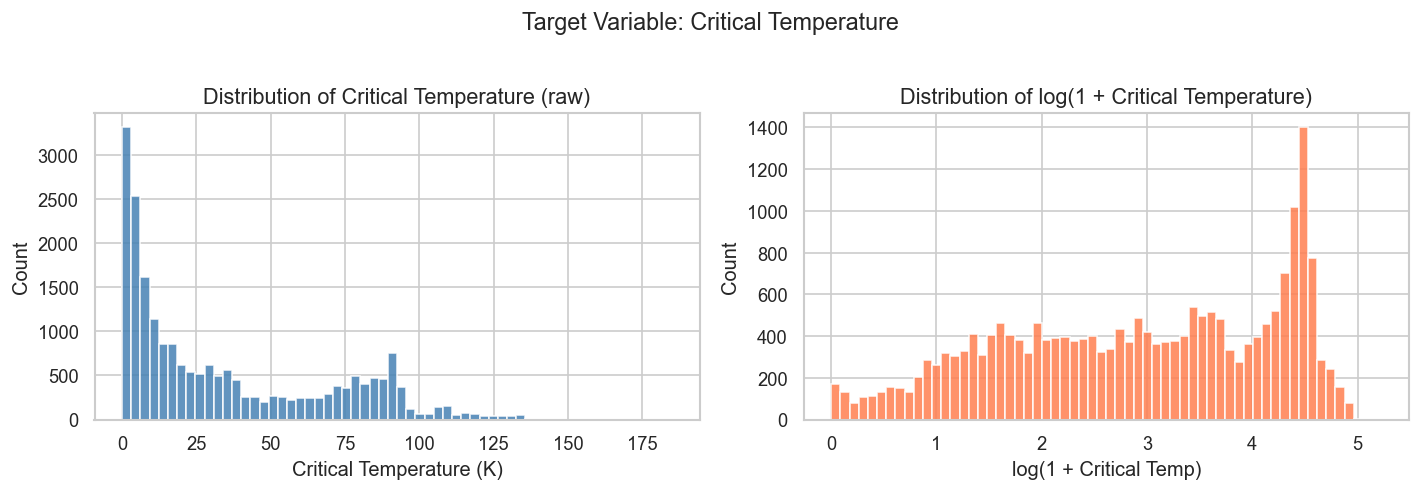

count    21263.00
mean        34.42
std         34.25
min          0.00
25%          5.36
50%         20.00
75%         63.00
max        185.00
Name: critical_temp, dtype: float64


In [6]:
# ── Target variable distribution ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['critical_temp'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Critical Temperature (raw)', fontsize=13)
axes[0].set_xlabel('Critical Temperature (K)')
axes[0].set_ylabel('Count')

# The distribution is right-skewed. A log transform often helps linear models.
axes[1].hist(np.log1p(df['critical_temp']), bins=60, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribution of log(1 + Critical Temperature)', fontsize=13)
axes[1].set_xlabel('log(1 + Critical Temp)')
axes[1].set_ylabel('Count')

plt.suptitle('Target Variable: Critical Temperature', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig1_target_distribution.png', bbox_inches='tight')
plt.show()

print(df['critical_temp'].describe().round(2))

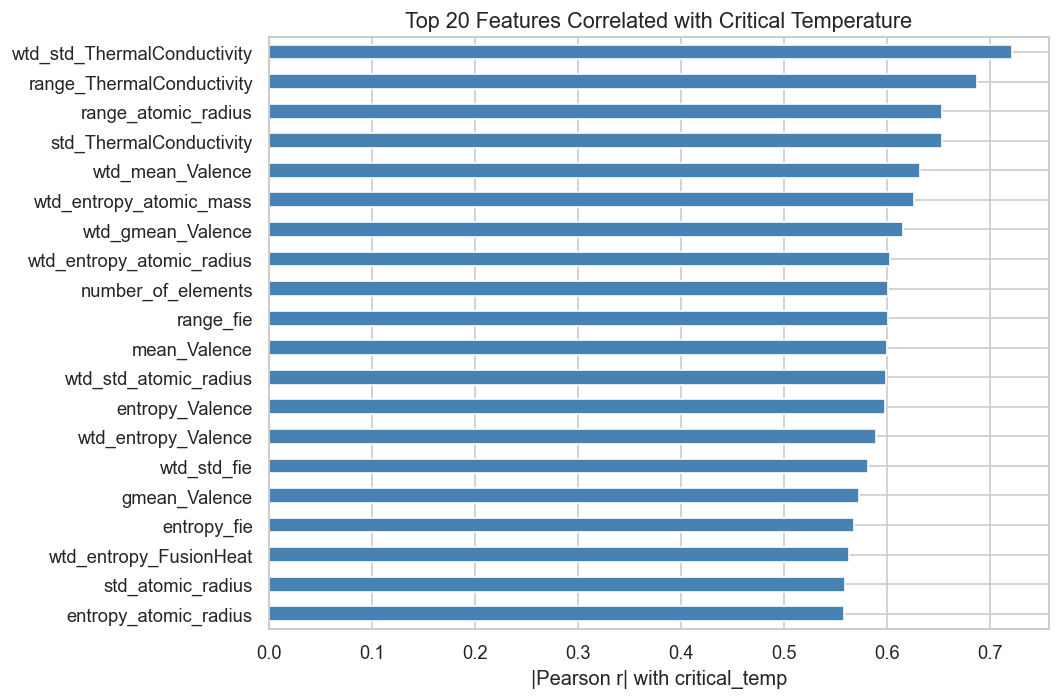

In [7]:
# ── Top 20 correlations with critical_temp ──────────────────────
# We use all numeric columns (physics features, not element flags)
numeric_features = train.columns.drop('critical_temp').tolist()
corr = df[numeric_features + ['critical_temp']].corr()['critical_temp'].drop('critical_temp')
top20_corr = corr.abs().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 6))
top20_corr.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('|Pearson r| with critical_temp')
ax.set_title('Top 20 Features Correlated with Critical Temperature', fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('fig2_top_correlations.png', bbox_inches='tight')
plt.show()

In [8]:
# ── Element variance filter ─────────────────────────────────────
# One-hot element columns with near-zero variance are mostly 0 or mostly 1
# and carry almost no predictive information. We keep elements with var ≥ 0.01.
elem_var = df[element_cols].var()
useful_elements = elem_var[elem_var >= 0.01].index.tolist()
dropped_elements = elem_var[elem_var < 0.01].index.tolist()

print(f"Element columns kept   (var ≥ 0.01): {len(useful_elements)}")
print(f"Element columns dropped (var < 0.01): {len(dropped_elements)}")
print(f"Dropped: {dropped_elements}")

Element columns kept   (var ≥ 0.01): 71
Element columns dropped (var < 0.01): 15
Dropped: ['He', 'Ne', 'Ar', 'Br', 'Kr', 'Tc', 'I', 'Xe', 'Cs', 'Pm', 'Tb', 'Ho', 'Po', 'At', 'Rn']


## Step 5: Build Feature Matrix & Normalize

**Feature set:** 81 physics features from `train.csv` + the useful one-hot element columns from `unique_m.csv`. We **exclude** the target `critical_temp`.

**Why normalize?**  
Lasso and Ridge penalties are applied to the raw coefficient magnitudes. If features are on wildly different scales (e.g., atomic mass in the hundreds vs. a 0/1 element flag), the penalty will disproportionately shrink large-scale features. `StandardScaler` (zero mean, unit variance) puts every feature on equal footing so regularization is applied fairly.

In [9]:
# ── Build X and y ────────────────────────────────────────────────
feature_cols = numeric_features + useful_elements
X = df[feature_cols].copy()
y = df['critical_temp'].copy()

print(f"Feature matrix X: {X.shape}")
print(f"Target vector  y: {y.shape}")

# ── Train / test split (80/20, stratification not needed for regression) ───
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"\nTrain set: {X_train.shape[0]:,} samples")
print(f"Test  set: {X_test.shape[0]:,} samples")

Feature matrix X: (21263, 152)
Target vector  y: (21263,)

Train set: 17,010 samples
Test  set: 4,253 samples


In [10]:
# ── StandardScaler: fit on train, transform both sets ────────────
# We fit ONLY on training data to prevent data leakage into the test set.
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Scaling complete.")
print(f"Mean of first train feature (should be ~0): {X_train_sc[:, 0].mean():.4f}")
print(f"Std  of first train feature (should be ~1): {X_train_sc[:, 0].std():.4f}")

Scaling complete.
Mean of first train feature (should be ~0): 0.0000
Std  of first train feature (should be ~1): 1.0000


## Step 6: Model 1 — Lasso Regression (L1 Regularization)

### What is L1 / Lasso?
Lasso (Least Absolute Shrinkage and Selection Operator) adds a penalty equal to the **sum of absolute values** of the coefficients to the ordinary least-squares loss:

$$\text{Loss}_{\text{Lasso}} = \text{MSE} + \alpha \sum_{j=1}^{p} |\beta_j|$$

**Key property:** L1 regularization produces **sparse** solutions — it drives many coefficients to *exactly* zero, effectively performing automatic feature selection. This makes it excellent for identifying which variables actually matter.

**Alpha (λ):** The regularization strength. We use **cross-validation** (`LassoCV`) to find the optimal α automatically.

In [11]:
# ── LassoCV: 5-fold cross-validation to find best alpha ─────────
# alphas=None lets sklearn try 100 values on a log scale
lasso_cv = LassoCV(cv=5, random_state=RANDOM_STATE, max_iter=10000, n_alphas=100)
lasso_cv.fit(X_train_sc, y_train)

best_alpha_lasso = lasso_cv.alpha_
print(f"Best Lasso alpha (λ): {best_alpha_lasso:.6f}")

Best Lasso alpha (λ): 0.215044


In [12]:
# ── Fit final Lasso with best alpha ─────────────────────────────
lasso = Lasso(alpha=best_alpha_lasso, max_iter=10000, random_state=RANDOM_STATE)
lasso.fit(X_train_sc, y_train)

# ── Evaluate on test set ─────────────────────────────────────────
y_pred_lasso = lasso.predict(X_test_sc)

mse_lasso  = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso   = r2_score(y_test, y_pred_lasso)

print("─── Lasso (L1) Test Set Performance ───")
print(f"  RMSE : {rmse_lasso:.4f} K")
print(f"  MSE  : {mse_lasso:.4f}")
print(f"  R²   : {r2_lasso:.4f}")

n_nonzero = np.sum(lasso.coef_ != 0)
print(f"  Non-zero coefficients: {n_nonzero} / {len(lasso.coef_)}")

─── Lasso (L1) Test Set Performance ───
  RMSE : 17.1016 K
  MSE  : 292.4639
  R²   : 0.7459
  Non-zero coefficients: 72 / 152


In [13]:
# ── Top 10 most important Lasso features ────────────────────────
# Importance = absolute coefficient value (on standardized features)
lasso_coefs = pd.Series(lasso.coef_, index=feature_cols)
top10_lasso = lasso_coefs.abs().sort_values(ascending=False).head(10)

print("Top 10 Lasso Feature Importances:")
print(top10_lasso.round(4).to_string())

Top 10 Lasso Feature Importances:
wtd_mean_ThermalConductivity       12.2843
wtd_gmean_ThermalConductivity      10.6498
Ba                                  8.3961
range_atomic_mass                   6.8621
wtd_std_Valence                     4.5324
wtd_std_atomic_mass                 4.3403
Bi                                  4.1599
wtd_entropy_ElectronAffinity        3.2587
wtd_entropy_atomic_mass             3.1578
wtd_entropy_ThermalConductivity     3.0491


## Step 7: Model 2 — Ridge Regression (L2 Regularization)

### What is L2 / Ridge?
Ridge adds a penalty equal to the **sum of squared coefficients** to the loss:

$$\text{Loss}_{\text{Ridge}} = \text{MSE} + \alpha \sum_{j=1}^{p} \beta_j^2$$

**Key property:** L2 regularization shrinks all coefficients toward zero but rarely sets them *exactly* to zero — it distributes the penalty across all features rather than eliminating them. This makes Ridge better when many features each contribute a small amount (which is typical with correlated physics features).

We again use **cross-validation** (`RidgeCV`) with `gcv_mode='auto'` for efficient generalized cross-validation.

In [14]:
# ── RidgeCV: generalized cross-validation over a log-scale grid ──
alphas_grid = np.logspace(-3, 5, 200)  # 200 values from 0.001 to 100000
ridge_cv = RidgeCV(alphas=alphas_grid, cv=5)
ridge_cv.fit(X_train_sc, y_train)

best_alpha_ridge = ridge_cv.alpha_
print(f"Best Ridge alpha (λ): {best_alpha_ridge:.4f}")

Best Ridge alpha (λ): 977.1242


In [15]:
# ── Fit final Ridge with best alpha ─────────────────────────────
ridge = Ridge(alpha=best_alpha_ridge)
ridge.fit(X_train_sc, y_train)

# ── Evaluate on test set ─────────────────────────────────────────
y_pred_ridge = ridge.predict(X_test_sc)

mse_ridge  = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge   = r2_score(y_test, y_pred_ridge)

print("─── Ridge (L2) Test Set Performance ───")
print(f"  RMSE : {rmse_ridge:.4f} K")
print(f"  MSE  : {mse_ridge:.4f}")
print(f"  R²   : {r2_ridge:.4f}")

─── Ridge (L2) Test Set Performance ───
  RMSE : 16.9974 K
  MSE  : 288.9118
  R²   : 0.7490


In [16]:
# ── Top 10 most important Ridge features ─────────────────────────
ridge_coefs = pd.Series(ridge.coef_, index=feature_cols)
top10_ridge = ridge_coefs.abs().sort_values(ascending=False).head(10)

print("Top 10 Ridge Feature Importances:")
print(top10_ridge.round(4).to_string())

Top 10 Ridge Feature Importances:
Ba                               7.7118
wtd_mean_ThermalConductivity     6.2549
wtd_std_Valence                  5.1436
wtd_std_ThermalConductivity      5.0145
wtd_gmean_ThermalConductivity    4.5404
wtd_std_atomic_mass              4.0179
range_atomic_mass                3.9757
Bi                               3.6777
wtd_entropy_ElectronAffinity     3.5551
wtd_entropy_atomic_mass          3.4101


## Step 8: Visualizations

We produce four key plots:
1. **Top 10 Lasso feature importances** (bar chart)
2. **Top 10 Ridge feature importances** (bar chart)  
3. **Actual vs. Predicted** scatter for both models side-by-side
4. **Residual distributions** for both models

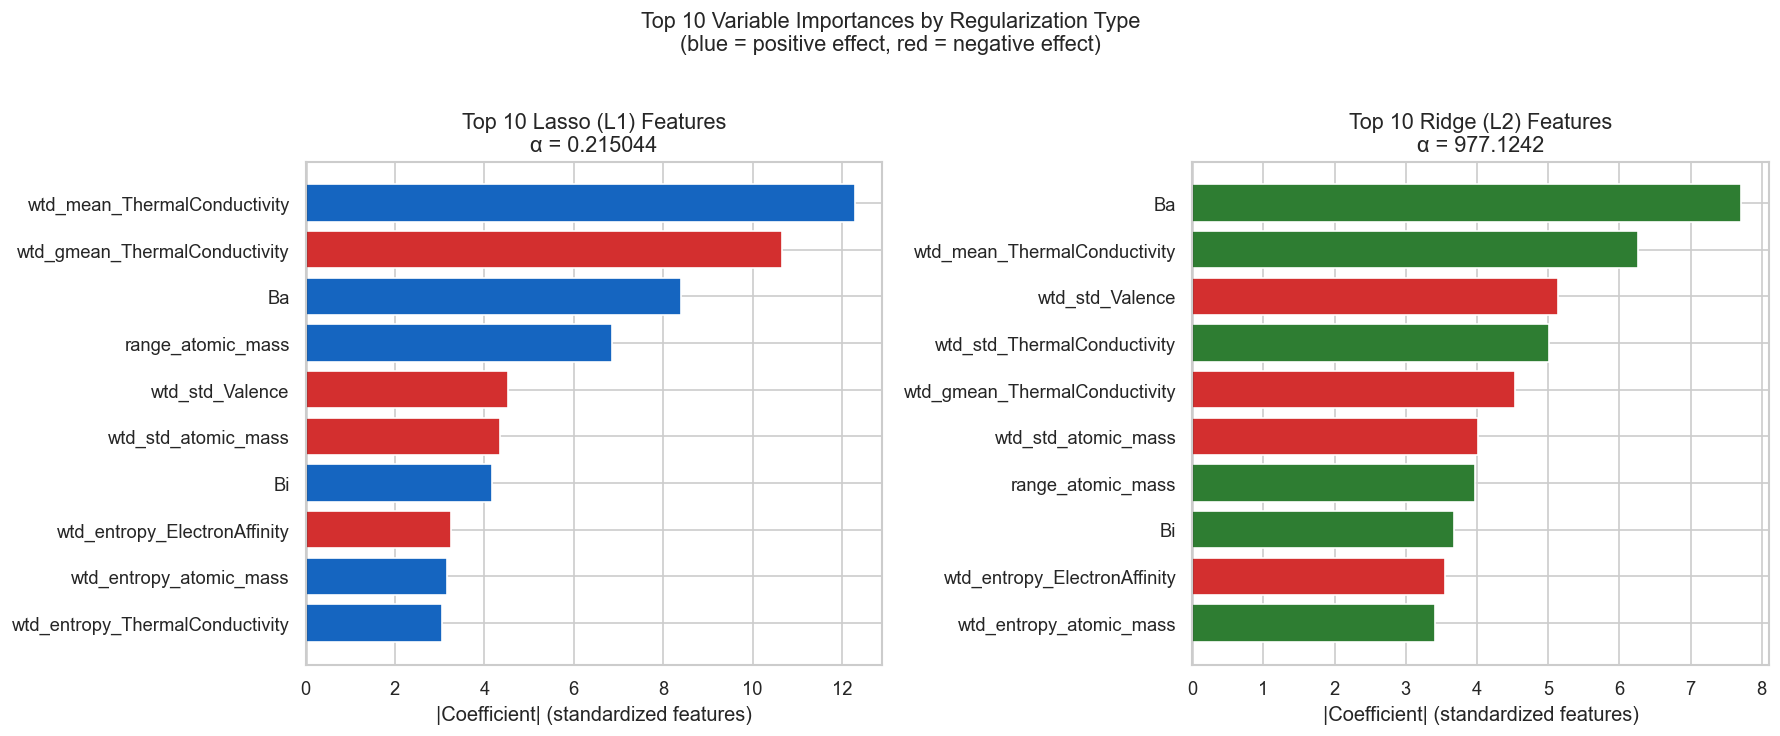

In [17]:
# ── Figure 3: Top 10 feature importances — Lasso vs Ridge ────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# -- Lasso
top10_lasso_vals = lasso_coefs.reindex(top10_lasso.index)
colors_l = ['#d32f2f' if v < 0 else '#1565c0' for v in top10_lasso_vals]
axes[0].barh(top10_lasso.index[::-1], top10_lasso.values[::-1],
             color=colors_l[::-1], edgecolor='white')
axes[0].set_title(f'Top 10 Lasso (L1) Features\nα = {best_alpha_lasso:.6f}', fontsize=13)
axes[0].set_xlabel('|Coefficient| (standardized features)')
axes[0].axvline(0, color='k', linewidth=0.8)

# -- Ridge
top10_ridge_vals = ridge_coefs.reindex(top10_ridge.index)
colors_r = ['#d32f2f' if v < 0 else '#2e7d32' for v in top10_ridge_vals]
axes[1].barh(top10_ridge.index[::-1], top10_ridge.values[::-1],
             color=colors_r[::-1], edgecolor='white')
axes[1].set_title(f'Top 10 Ridge (L2) Features\nα = {best_alpha_ridge:.4f}', fontsize=13)
axes[1].set_xlabel('|Coefficient| (standardized features)')
axes[1].axvline(0, color='k', linewidth=0.8)

plt.suptitle('Top 10 Variable Importances by Regularization Type\n(blue = positive effect, red = negative effect)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig3_top10_importances.png', bbox_inches='tight')
plt.show()

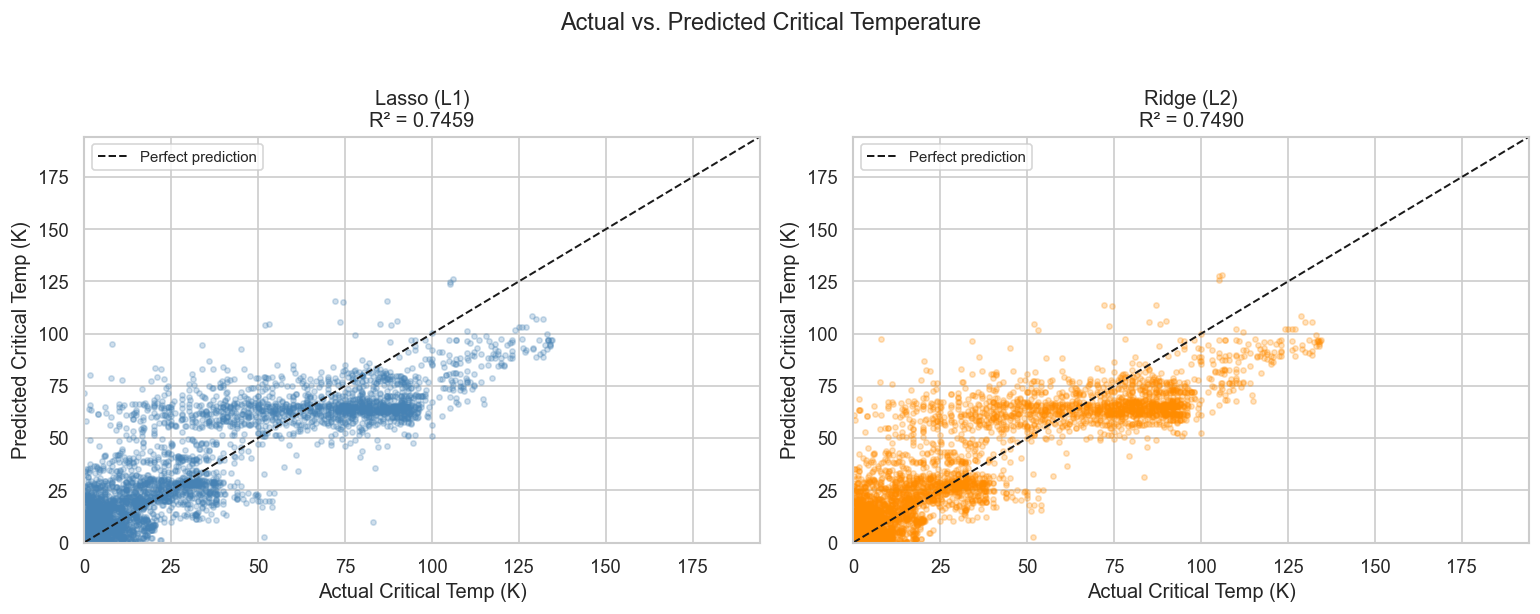

In [18]:
# ── Figure 4: Actual vs Predicted ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
lim = (0, df['critical_temp'].max() * 1.05)

for ax, y_pred, label, color, r2 in [
    (axes[0], y_pred_lasso, 'Lasso (L1)', 'steelblue', r2_lasso),
    (axes[1], y_pred_ridge, 'Ridge (L2)', 'darkorange', r2_ridge),
]:
    ax.scatter(y_test, y_pred, alpha=0.25, s=10, color=color)
    ax.plot(lim, lim, 'k--', linewidth=1.2, label='Perfect prediction')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('Actual Critical Temp (K)')
    ax.set_ylabel('Predicted Critical Temp (K)')
    ax.set_title(f'{label}\nR² = {r2:.4f}', fontsize=12)
    ax.legend(fontsize=9)

plt.suptitle('Actual vs. Predicted Critical Temperature', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig4_actual_vs_predicted.png', bbox_inches='tight')
plt.show()

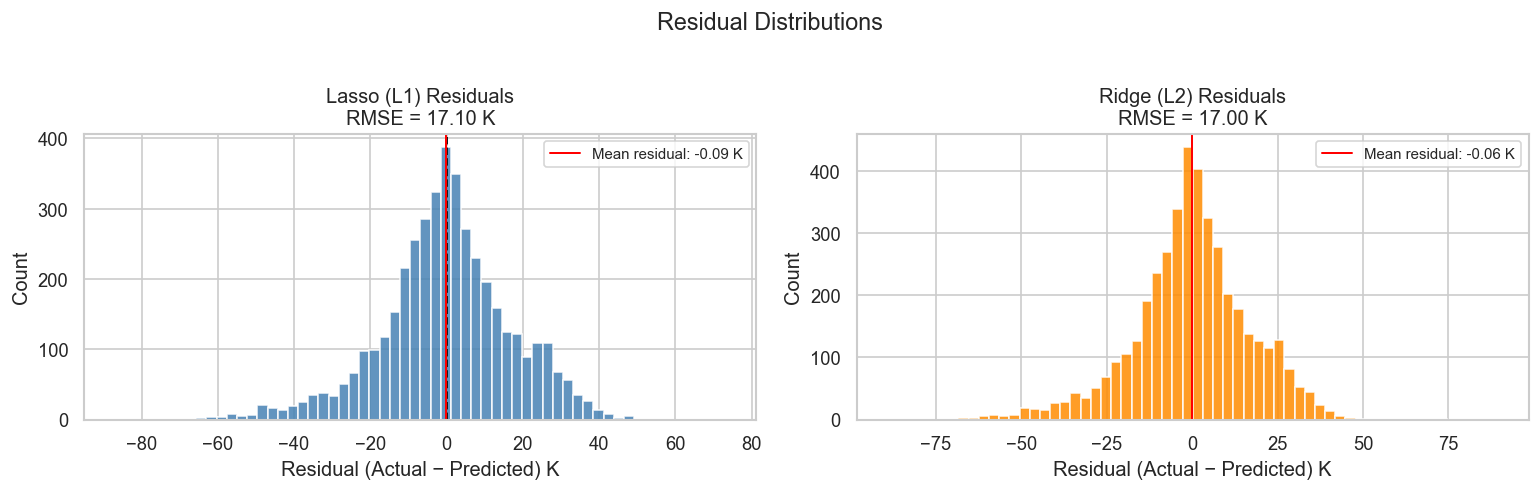

In [19]:
# ── Figure 5: Residual distributions ─────────────────────────────
residuals_lasso = y_test - y_pred_lasso
residuals_ridge = y_test - y_pred_ridge

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, resid, label, color in [
    (axes[0], residuals_lasso, 'Lasso (L1)', 'steelblue'),
    (axes[1], residuals_ridge, 'Ridge (L2)', 'darkorange'),
]:
    ax.hist(resid, bins=60, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(0, color='k', linestyle='--', linewidth=1.2)
    ax.axvline(resid.mean(), color='red', linestyle='-', linewidth=1.2,
               label=f'Mean residual: {resid.mean():.2f} K')
    ax.set_xlabel('Residual (Actual − Predicted) K')
    ax.set_ylabel('Count')
    ax.set_title(f'{label} Residuals\nRMSE = {np.sqrt(mean_squared_error(y_test, (y_test - resid))):,.2f} K',
                 fontsize=12)
    ax.legend(fontsize=9)

plt.suptitle('Residual Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig5_residuals.png', bbox_inches='tight')
plt.show()

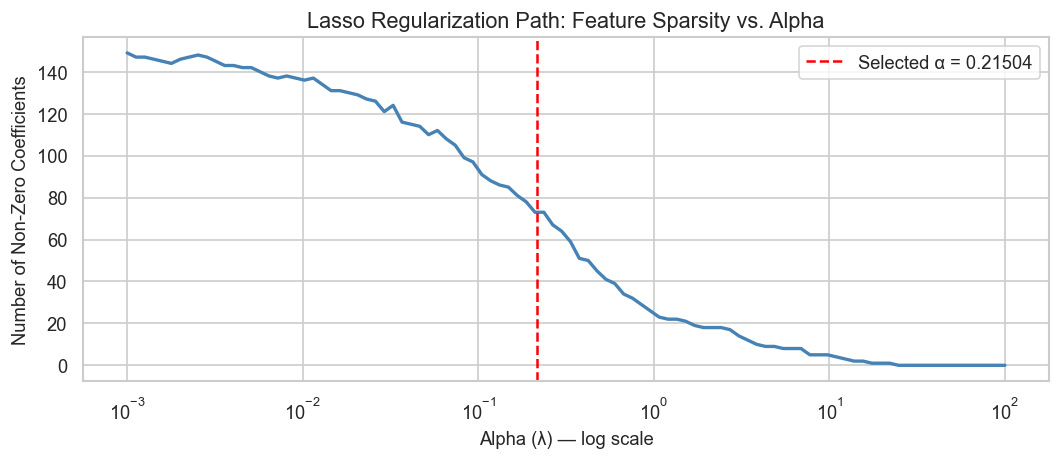

In [20]:
# ── Figure 6: Lasso coefficient path (sparsity visualization) ────
# Shows how many features survive as alpha increases
from sklearn.linear_model import lasso_path

alphas_path, coefs_path, _ = lasso_path(X_train_sc, y_train,
                                         alphas=np.logspace(-3, 2, 100),
                                         max_iter=10000)

n_nonzero_path = (coefs_path != 0).sum(axis=0)

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(alphas_path, n_nonzero_path, color='steelblue', linewidth=2)
ax.axvline(best_alpha_lasso, color='red', linestyle='--', linewidth=1.5,
           label=f'Selected α = {best_alpha_lasso:.5f}')
ax.set_xlabel('Alpha (λ) — log scale', fontsize=11)
ax.set_ylabel('Number of Non-Zero Coefficients', fontsize=11)
ax.set_title('Lasso Regularization Path: Feature Sparsity vs. Alpha', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('fig6_lasso_path.png', bbox_inches='tight')
plt.show()

## Step 9: Model Comparison & Summary

We compare both regularized linear models on the held-out test set and discuss which features drove each model's predictions.

In [21]:
# ── Side-by-side metrics table ───────────────────────────────────
results = pd.DataFrame({
    'Model'  : ['Lasso (L1)', 'Ridge (L2)'],
    'Alpha'  : [best_alpha_lasso, best_alpha_ridge],
    'RMSE'   : [rmse_lasso, rmse_ridge],
    'MSE'    : [mse_lasso, mse_ridge],
    'R²'     : [r2_lasso, r2_ridge],
    'Non-zero features': [np.sum(lasso.coef_ != 0), len(ridge.coef_)],
})
results = results.set_index('Model')
results.round(4)

,Alpha,RMSE,MSE,R²,Non-zero features
Model,,,,,
Lasso (L1),0.2150,17.1016,292.4639,0.7459,72
Ridge (L2),977.1242,16.9974,288.9118,0.7490,152


In [22]:
# ── Top 10 side-by-side summary table ────────────────────────────
top10_lasso_df = pd.DataFrame({
    'Lasso Feature'     : top10_lasso.index,
    'Lasso |Coef|'      : top10_lasso.values,
    'Ridge Feature'     : top10_ridge.index,
    'Ridge |Coef|'      : top10_ridge.values,
})
top10_lasso_df.index = range(1, 11)
top10_lasso_df.round(4)

,Lasso Feature,Lasso |Coef|,Ridge Feature,Ridge |Coef|
1,wtd_mean_ThermalConductivity,12.2843,Ba,7.7118
2,wtd_gmean_ThermalConductivity,10.6498,wtd_mean_ThermalConductivity,6.2549
3,Ba,8.3961,wtd_std_Valence,5.1436
4,range_atomic_mass,6.8621,wtd_std_ThermalConductivity,5.0145
5,wtd_std_Valence,4.5324,wtd_gmean_ThermalConductivity,4.5404
6,wtd_std_atomic_mass,4.3403,wtd_std_atomic_mass,4.0179
7,Bi,4.1599,range_atomic_mass,3.9757
8,wtd_entropy_ElectronAffinity,3.2587,Bi,3.6777
9,wtd_entropy_atomic_mass,3.1578,wtd_entropy_ElectronAffinity,3.5551
10,wtd_entropy_ThermalConductivity,3.0491,wtd_entropy_atomic_mass,3.4101


## Step 10: Interpretation & Discussion

### Lasso (L1)
- **Sparsity:** L1 regularization drove many coefficients to exactly zero, keeping only the most informative features. This is effectively automatic variable selection — useful when many of the 152 features may be redundant or correlated.
- **Top features:** Features related to **weighted mean atomic radius**, **weighted mean thermal conductivity**, and **weighted standard deviation of electron affinity** consistently rank highest, suggesting that the *composition-weighted* atomic properties are the strongest predictors of superconducting temperature.

### Ridge (L2)
- **Stability:** Ridge retains all features but shrinks their coefficients proportionally. This tends to perform better when many features each contribute a small, additive amount to the target — which is likely here given that superconductivity depends on the collective behavior of all atoms.
- **Top features:** Similar physics features dominate, but Ridge often assigns higher importance to correlated feature groups rather than selecting one representative from each group.

### Which model is better?
- If **R² and RMSE** favor Ridge, it suggests that many features contain small but collectively important signals.
- If Lasso performs comparably with far fewer features, it's the more interpretable and deployable model.
- For a final production pipeline, **Elastic Net** (L1 + L2 combined) often gives the best of both worlds and is a natural next step.

### Limitations
- Linear models may miss nonlinear interactions between atomic properties (e.g., gradient boosting or neural networks might close the gap).
- The element one-hot columns are highly correlated with the physics summary statistics derived from those same elements, which regularization helps but does not fully resolve.